The `dPULearn().compare_sets_negatives()` method facilitates the comparison of identified negative samples across datasets. Providing identified negatives represented by '0' in the ``list_labels`` input, it returns a DataFrame (typically named ``df_neg_comp``) where each row is a sample and each column a dataset, indicating whether the sample is identified as a negative (True) or not (False) in the respective dataset:

In [1]:
import aaanalysis as aa
list_labels = [[1, 1, 0, 0, 2], [1, 1, 0, 2, 0], [1, 1, 2, 0, 0]]
dpul = aa.dPULearn()
df_neg_comp = dpul.compare_sets_negatives(list_labels=list_labels)
aa.display_df(df_neg_comp)

,Set 1,Set 2,Set 3
3,True,True,False
4,True,False,True
5,False,True,True


By default, only rows containing at least one identified negative are returned. To return all rows, set ``remove_non_neg=False``: 

In [2]:
df_neg_comp = dpul.compare_sets_negatives(list_labels=list_labels, remove_non_neg=False)
aa.display_df(df_neg_comp)

,Set 1,Set 2,Set 3
1,False,False,False
2,False,False,False
3,True,True,False
4,True,False,True
5,False,True,True


Names of the datasets can be provided by the ``names_datasets`` argument: 

In [3]:
names = ["Dataset 1", "Dataset 2", "Dataset 3"]
df_neg_comp = dpul.compare_sets_negatives(list_labels=list_labels, names_datasets=names)
aa.display_df(df_neg_comp)

,Dataset 1,Dataset 2,Dataset 3
3,True,True,False
4,True,False,True
5,False,True,True


A DataFrame with sequence information (``df_seq``) and an required 'entry' column can be provided, which is then merged with the ``df_neg_comp`` output DataFrame:

In [4]:
import pandas as pd
df_seq = pd.DataFrame([("entry1", "AA"), ("entry2", "BB"), ("entry3", "CC"), ("entry4", "DD"), ("entry5", "EE")], columns=["entry", "sequence"])
df_neg_comp = dpul.compare_sets_negatives(list_labels=list_labels, df_seq=df_seq)
aa.display_df(df_neg_comp)

,entry,sequence,Set 1,Set 2,Set 3
3,entry3,CC,True,True,False
4,entry4,DD,True,False,True
5,entry5,EE,False,True,True


Such overlaps are conveniently visualized using Venn diagrams, but they are limited to a maximum of three datasets. For comparing more than three datasets, an Upset Plot is a better choice. To facilitate this, set ``return_upset_data=True`` to generate a data structure directly compatible with the Upset Plot visualizations:   

DataFrame shape: (2, 5)


,Set 1,Set 2,Set 3,Set 4,n_samples
1,False,True,True,True,2
2,True,False,False,True,1


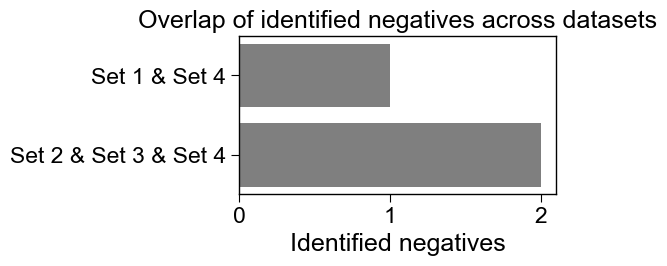

In [5]:
import matplotlib.pyplot as plt
list_labels = [[1, 1, 0, 2, 2], [1, 1, 2, 0, 0], [1, 1, 2, 0, 0], [1, 1, 0, 0, 0]]
upset_data = dpul.compare_sets_negatives(list_labels=list_labels, return_upset_data=True)
# A Series indexed by one boolean level per dataset (True = sample is a negative there),
# valued by the number of samples with exactly that membership pattern:
aa.display_df(upset_data.reset_index(name="n_samples"), n_rows=10, show_shape=True)

# ``upsetplot.plot(upset_data, show_counts='%d')`` draws the UpSet diagram from this Series
# (upsetplot 0.9 does not run on pandas >= 3, so the intersections are drawn directly here).
labels = [" & ".join(name for name, flag in zip(upset_data.index.names, idx) if flag)
          for idx in upset_data.index]
aa.plot_settings(weight_bold=False)
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(labels, upset_data.values, color=aa.plot_get_clist(n_colors=3)[0])
ax.set_xlabel("Identified negatives")
ax.set_title("Overlap of identified negatives across datasets")
plt.tight_layout()
plt.show()